# **machine learning based Instagram Marketing Strategy**

Sector and Industry analysis

## Loading Data

In [5]:
import pandas as pd

# Loading Stock Sector and Industry Data
sector_industry_yf = pd.read_csv("/Users/ragiakshayareddy/Downloads/instagram_rl_strategy/data/sector_industry_yf.csv")
sector_industry_yf.head()

,symbol,sector,industry
0,BRK-A,Financial Services,Insurance - Diversified
1,NVR,Consumer Cyclical,Residential Construction
2,SEB,Industrials,Conglomerates
3,BKNG,Consumer Cyclical,Travel Services
4,AZO,Consumer Cyclical,Auto Parts


In [6]:
# Loading Stocks Data
data_yf = pd.read_csv("/Users/ragiakshayareddy/Downloads/instagram_rl_strategy/data/data_yf.csv")
data_yf.head()

,language,region,quoteType,typeDisp,quoteSourceName,triggerable,customPriceAlertConfidence,currency,hasPrePostMarketData,firstTradeDateMilliseconds,...,tickerChangeDate,prevExchange,exchangeTransferDate,netExpenseRatio,netAssets,ytdReturn,trailingThreeMonthReturns,trailingThreeMonthNavReturns,newListingDate,openInterest
0,en-US,US,EQUITY,Equity,Delayed Quote,False,LOW,USD,True,3.221514e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,USD,True,4.908870e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,USD,True,9.923940e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,True,HIGH,USD,True,9.228906e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,USD,True,6.706026e+11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Merging Datasets

In [7]:
sector_industry_stocks_merged = sector_industry_yf.merge(
    data_yf,
    on="symbol",
    how="left"
)
sector_industry_stocks_merged

,symbol,sector,industry,language,region,quoteType,typeDisp,quoteSourceName,triggerable,customPriceAlertConfidence,...,tickerChangeDate,prevExchange,exchangeTransferDate,netExpenseRatio,netAssets,ytdReturn,trailingThreeMonthReturns,trailingThreeMonthNavReturns,newListingDate,openInterest
0,BRK-A,Financial Services,Insurance - Diversified,en-US,US,EQUITY,Equity,Delayed Quote,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NVR,Consumer Cyclical,Residential Construction,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SEB,Industrials,Conglomerates,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BKNG,Consumer Cyclical,Travel Services,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,True,HIGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AZO,Consumer Cyclical,Auto Parts,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,MT,NaN,NaN,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1295,NWN,NaN,NaN,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1296,MKC-V,NaN,NaN,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1297,FBK,NaN,NaN,en-US,US,EQUITY,Equity,Nasdaq Real Time Price,False,LOW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Getting Data Structure
sector_industry_stocks_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 98 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   symbol                             1299 non-null   object 
 1   sector                             909 non-null    object 
 2   industry                           909 non-null    object 
 3   language                           1299 non-null   object 
 4   region                             1299 non-null   object 
 5   quoteType                          1299 non-null   object 
 6   typeDisp                           1299 non-null   object 
 7   quoteSourceName                    1299 non-null   object 
 8   triggerable                        1299 non-null   bool   
 9   customPriceAlertConfidence         1299 non-null   object 
 10  currency                           1299 non-null   object 
 11  hasPrePostMarketData               1299 non-null   bool 

In [9]:
# Getting Subset for Relevant Variables
sector_industry_stocks_merged = sector_industry_stocks_merged[['symbol',	'sector',	'industry',	'twoHundredDayAverage', 'twoHundredDayAverageChange', 'fiftyDayAverage',  'fiftyDayAverageChange',
                               'regularMarketPrice', 'regularMarketChange', 'regularMarketVolume', 'averageDailyVolume3Month']]

sector_industry_stocks_merged.head()

,symbol,sector,industry,twoHundredDayAverage,twoHundredDayAverageChange,fiftyDayAverage,fiftyDayAverageChange,regularMarketPrice,regularMarketChange,regularMarketVolume,averageDailyVolume3Month
0,BRK-A,Financial Services,Insurance - Diversified,737042.5000,-14996.5000,738645.0600,-16599.06200,722046.000,2046.000000,93.0,661.0
1,NVR,Consumer Cyclical,Residential Construction,7582.0205,-1064.4604,7398.9775,-881.41750,6517.560,-13.129883,10414.0,27762.0
2,SEB,Industrials,Conglomerates,3970.6606,1227.3394,5000.1340,197.86621,5198.000,229.430180,12582.0,20488.0
3,BKNG,Consumer Cyclical,Travel Services,5180.9710,-889.8462,4592.2320,-301.10693,4291.125,-105.665040,167680.0,390672.0
4,AZO,Consumer Cyclical,Auto Parts,3797.7056,-446.7256,3644.6420,-293.66210,3350.980,-2.260010,44377.0,158708.0


In [10]:
sector_industry_stocks_merged.industry.value_counts()

industry
Software - Application            36
Banks - Regional                  32
Specialty Industrial Machinery    32
Aerospace & Defense               28
Biotechnology                     28
                                  ..
Department Stores                  1
Utilities - Regulated Water        1
Financial Conglomerates            1
Broadcasting                       1
Confectioners                      1
Name: count, Length: 129, dtype: int64

## Exploratory Data Analysis

In [11]:
# Aggregating by Sector
sector_volume_stats = sector_industry_stocks_merged.groupby('sector')[
    ['regularMarketVolume', 'averageDailyVolume3Month']
].mean().reset_index()
sector_volume_stats

,sector,regularMarketVolume,averageDailyVolume3Month
0,Basic Materials,9.200954e+05,1.597454e+06
1,Communication Services,3.063102e+06,6.427630e+06
2,Consumer Cyclical,1.296641e+06,2.710345e+06
3,Consumer Defensive,1.340156e+06,3.029395e+06
4,Energy,1.958354e+06,3.066142e+06
5,Financial Services,1.099989e+06,1.744920e+06
6,Healthcare,8.446274e+05,1.726149e+06
7,Industrials,5.173077e+05,1.224634e+06
8,Real Estate,5.003732e+05,1.326630e+06
9,Technology,3.439387e+06,6.119314e+06


/var/folders/bn/kdy8kr0500qdkg30xzf9chs80000gn/T/ipykernel_15444/2000150609.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


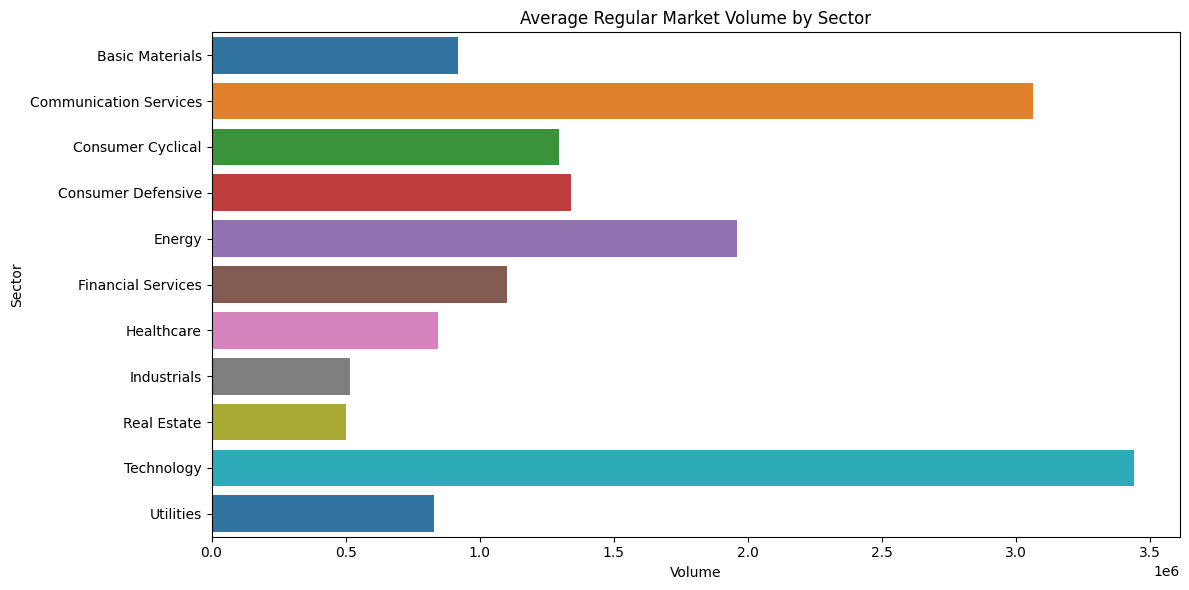

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


# Horizontal Bar Chart
plt.figure(figsize=(12, 6))

palette = sns.color_palette("tab10", n_colors=len(sector_volume_stats))

sns.barplot(
    data=sector_volume_stats,
    x='regularMarketVolume',
    y='sector',
    palette=palette
)

plt.title('Average Regular Market Volume by Sector')
plt.xlabel('Volume')
plt.ylabel('Sector')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1326/1982252164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


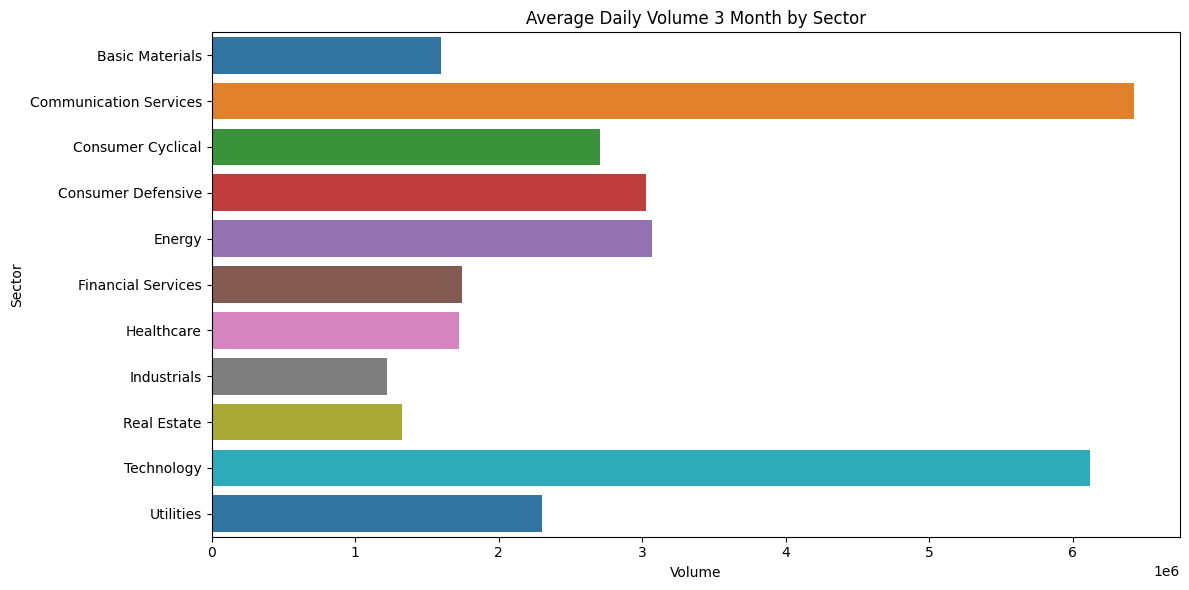

In [17]:

# Horizontal Bar Chart
plt.figure(figsize=(12, 6))

palette = sns.color_palette("tab10", n_colors=len(sector_volume_stats))

sns.barplot(
    data=sector_volume_stats,
    x='averageDailyVolume3Month',
    y='sector',
    palette=palette
)

plt.title('Average Daily Volume 3 Month by Sector')
plt.xlabel('Volume')
plt.ylabel('Sector')

plt.tight_layout()
plt.show()

In [13]:
# Aggregating by Industries within Technology and Commuication Services Sectors
tech_comms_sectors_df = sector_industry_stocks_merged[
    sector_industry_stocks_merged['sector'].isin(['Technology', 'Communication Services'])
]
tech_comms_sectors_df.head()

,symbol,sector,industry,twoHundredDayAverage,twoHundredDayAverageChange,fiftyDayAverage,fiftyDayAverageChange,regularMarketPrice,regularMarketChange,regularMarketVolume,averageDailyVolume3Month
10,KLAC,Technology,Semiconductor Equipment & Materials,1145.82210,415.79785,1469.8492,91.770750,1561.62,50.189940,433723.0,1097293.0
12,ASML,Technology,Semiconductor Equipment & Materials,1026.39820,366.89185,1387.1896,6.100464,1393.29,23.670044,1397677.0,1746291.0
17,MPWR,Technology,Semiconductors,926.73517,168.43488,1105.6716,-10.501587,1095.17,18.820068,198588.0,586596.0
20,FICO,Technology,Software - Application,1576.72940,-599.81940,1398.4874,-421.577450,976.91,-86.419980,309286.0,322933.0
30,UI,Technology,Communication Equipment,576.99760,256.57240,671.7010,161.869020,833.57,24.210022,75354.0,101961.0


In [14]:
industry_stats = tech_comms_sectors_df.groupby(
    ['sector', 'industry']
)[
    ['regularMarketVolume', 'averageDailyVolume3Month']
].mean().reset_index()

industry_stats

,sector,industry,regularMarketVolume,averageDailyVolume3Month
0,Communication Services,Advertising Agencies,1.539967e+06,3.642153e+06
1,Communication Services,Broadcasting,2.074950e+05,3.501710e+05
2,Communication Services,Electronic Gaming & Multimedia,8.554913e+05,1.834155e+06
3,Communication Services,Entertainment,2.223342e+06,6.486923e+06
4,Communication Services,Internet Content & Information,7.865047e+06,1.337364e+07
5,Communication Services,Publishing,1.210323e+06,2.270147e+06
6,Communication Services,Telecom Services,1.367974e+06,3.047126e+06
7,Technology,Communication Equipment,3.638106e+06,5.748730e+06
8,Technology,Computer Hardware,5.008636e+06,8.202104e+06
9,Technology,Consumer Electronics,1.671780e+07,4.658603e+07


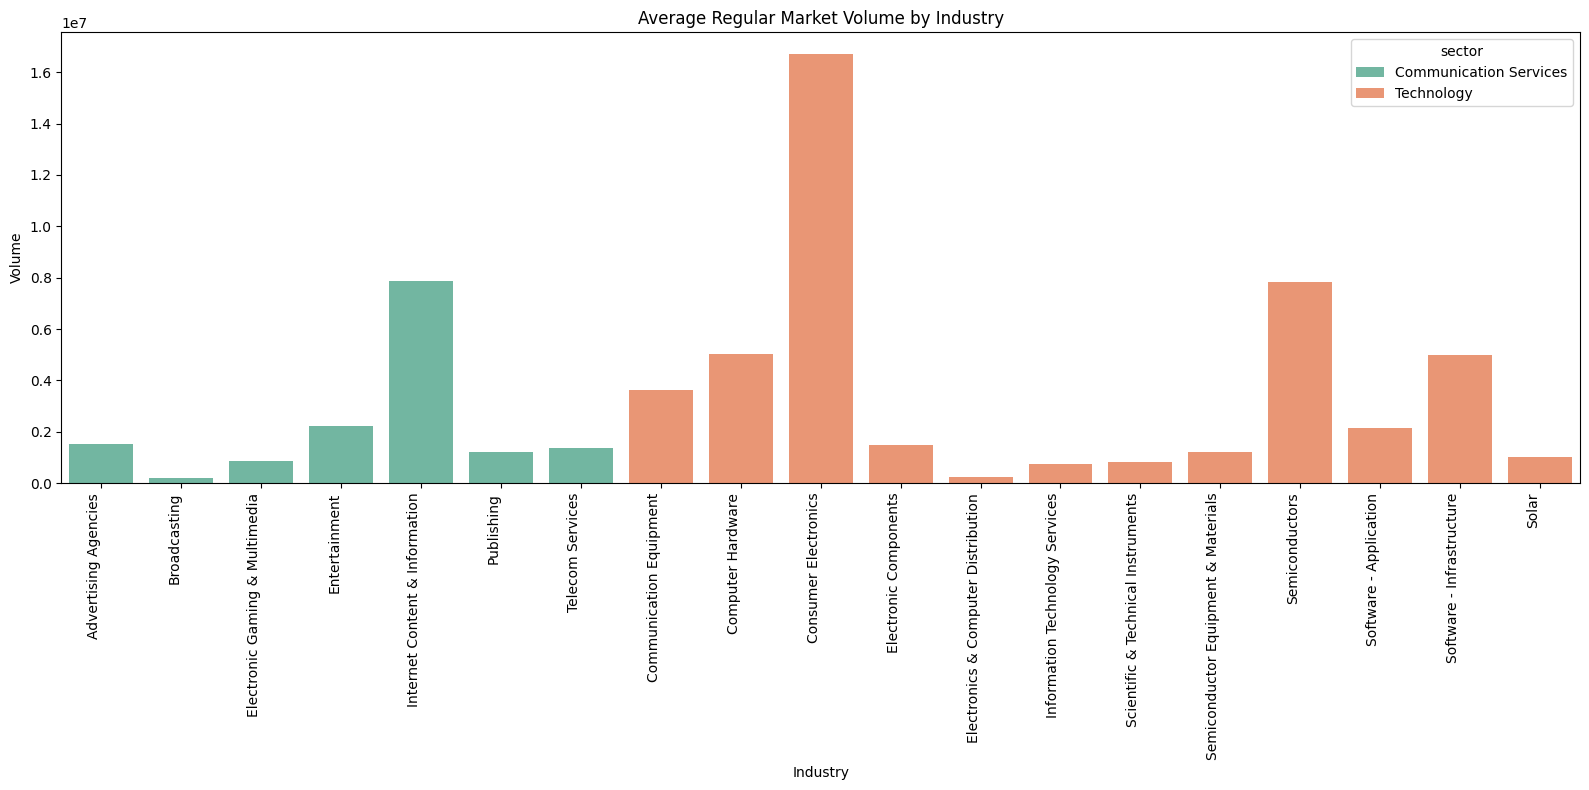

In [15]:
# Average Regular Market Volume by Industry

plt.figure(figsize=(16, 8))

sns.barplot(
    data=industry_stats,
    x='industry',
    y='regularMarketVolume',
    hue='sector',
    palette='Set2'
)

plt.title('Average Regular Market Volume by Industry')
plt.xlabel('Industry')
plt.ylabel('Volume')

plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

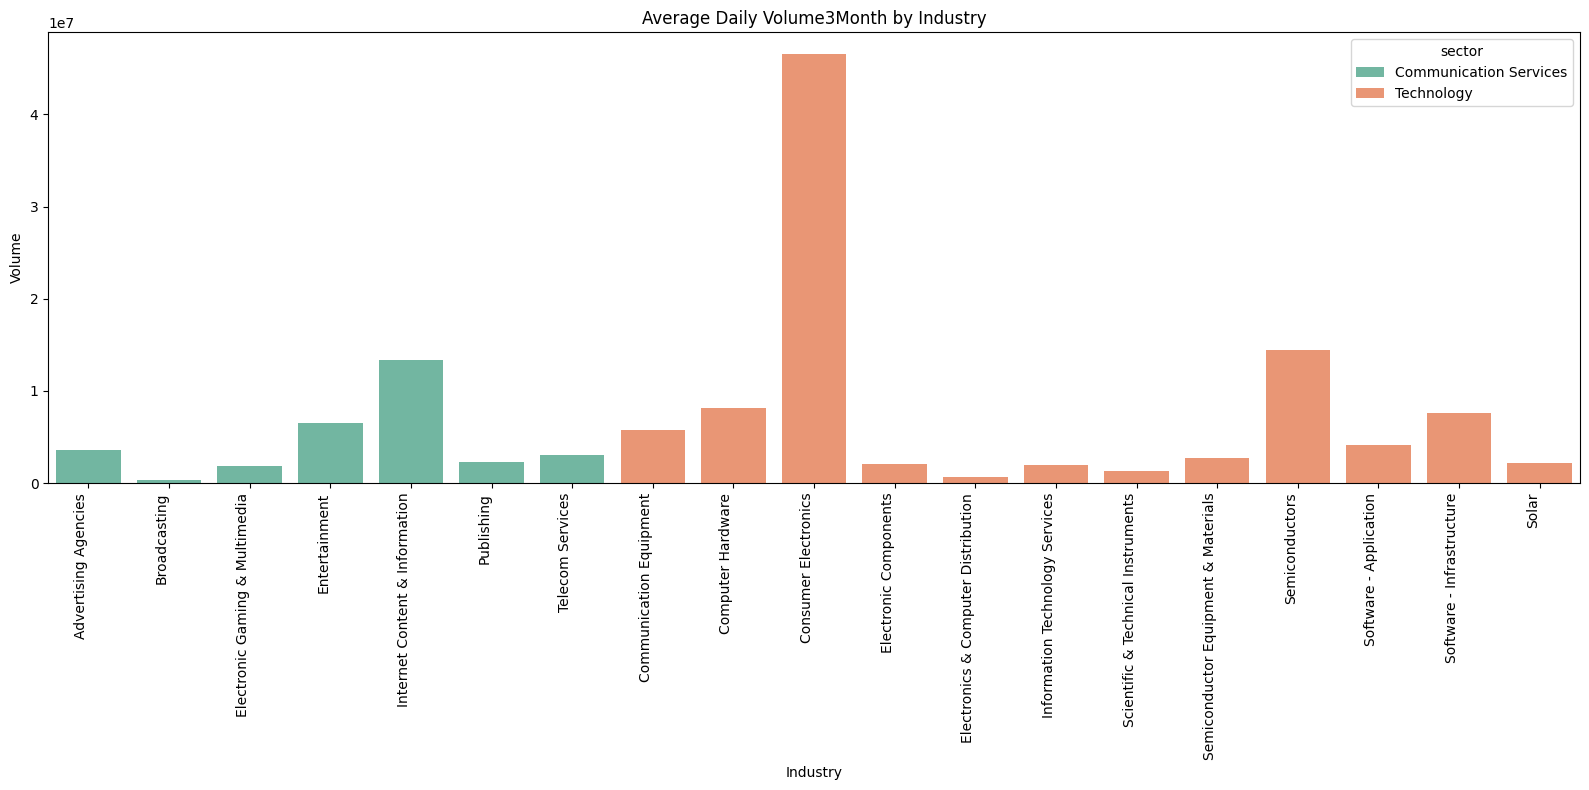

In [16]:
# Average Regular Market Volume by Industry

plt.figure(figsize=(16, 8))

sns.barplot(
    data=industry_stats,
    x='industry',
    y='averageDailyVolume3Month',
    hue='sector',
    palette='Set2'
)

plt.title('Average Daily Volume3Month by Industry')
plt.xlabel('Industry')
plt.ylabel('Volume')

plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

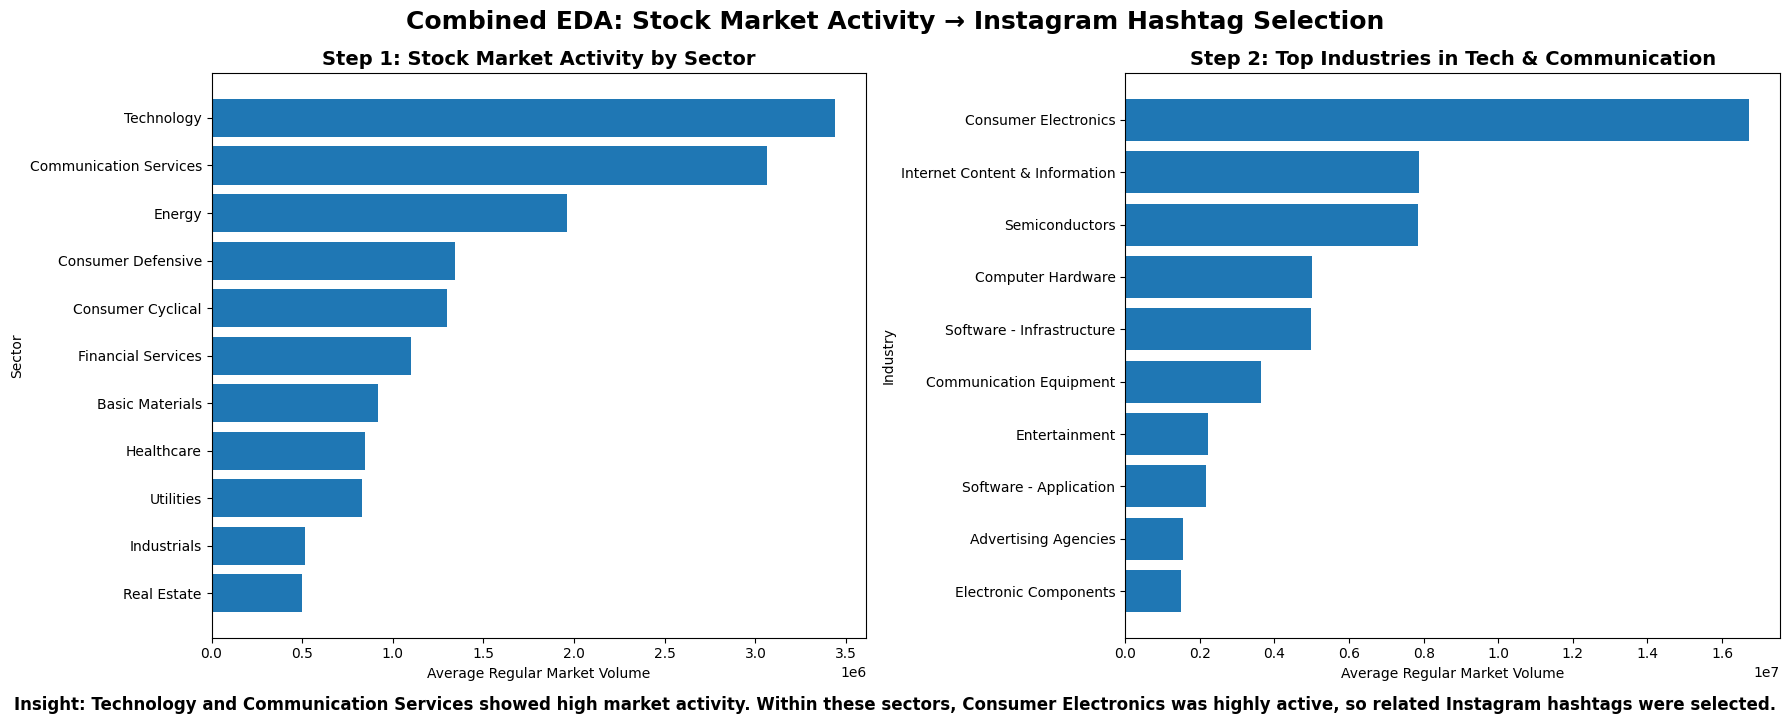

Saved visual at: /Users/ragiakshayareddy/Downloads/instagram_rl_strategy/data/combined_sector_industry_eda.png


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_path = "/Users/ragiakshayareddy/Downloads/instagram_rl_strategy/data"

# Load files
sector_industry_yf = pd.read_csv(os.path.join(base_path, "sector_industry_yf.csv"))
data_yf = pd.read_csv(os.path.join(base_path, "data_yf.csv"))

# Clean column names
sector_industry_yf.columns = sector_industry_yf.columns.str.strip()
data_yf.columns = data_yf.columns.str.strip()

# Merge sector/industry data with stock market data
df = sector_industry_yf.merge(
    data_yf,
    on="symbol",
    how="left"
)

# Keep needed columns
df = df[
    [
        "symbol",
        "sector",
        "industry",
        "regularMarketVolume",
        "averageDailyVolume3Month"
    ]
]

# Remove missing values
df = df.dropna(subset=["sector", "industry", "regularMarketVolume"])

# Sector summary
sector_volume_stats = (
    df.groupby("sector")["regularMarketVolume"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Focus only on Technology + Communication Services
tech_comms_df = df[
    df["sector"].isin(["Technology", "Communication Services"])
]

industry_stats = (
    tech_comms_df.groupby(["sector", "industry"])["regularMarketVolume"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Take top industries
top_industries = industry_stats.head(10)

# ---------------- COMBINED VISUAL ----------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left chart: sector
axes[0].barh(
    sector_volume_stats["sector"],
    sector_volume_stats["regularMarketVolume"]
)
axes[0].invert_yaxis()
axes[0].set_title("Step 1: Stock Market Activity by Sector", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Average Regular Market Volume")
axes[0].set_ylabel("Sector")

# Right chart: industry
axes[1].barh(
    top_industries["industry"],
    top_industries["regularMarketVolume"]
)
axes[1].invert_yaxis()
axes[1].set_title("Step 2: Top Industries in Tech & Communication", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Average Regular Market Volume")
axes[1].set_ylabel("Industry")

# Main title
fig.suptitle(
    "Combined EDA: Stock Market Activity → Instagram Hashtag Selection",
    fontsize=18,
    fontweight="bold"
)

# Insight text
fig.text(
    0.5,
    -0.02,
    "Insight: Technology and Communication Services showed high market activity. "
    "Within these sectors, Consumer Electronics was highly active, so related Instagram hashtags were selected.",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

# Save image
output_path = os.path.join(base_path, "combined_sector_industry_eda.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved visual at:", output_path)